# Day 5 – Linear Regression + Regularization
### 20-Day ML Revision Planner | Phase: Core ML

**Topics covered:**
1. Simple & Multiple Linear Regression
2. Polynomial Regression
3. Cost Function & Gradient Descent (recap)
4. The Normal Equation
5. Regression Assumptions
6. Regularization: Ridge (L2) and Lasso (L1)
7. Bias–Variance Intuition
8. Coding: Linear Regression from Scratch
9. Coding: Linear, Ridge, Lasso with scikit-learn — Model Comparison
10. Mini Project: House Price Prediction
11. Metrics: MAE, MSE, RMSE, R²
12. Interview Questions
13. Active Recall Checklist

**Revision rule:** Learn → Close Notes → Recall → Code → Debug → Explain → Interview Question.

---


In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing, make_regression

np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.precision', 4)
np.random.seed(42)
print("Setup complete.")


Setup complete.


## 1. Simple & Multiple Linear Regression

### What?
- **Simple linear regression**: models the relationship between **one** feature $x$ and a continuous target $y$ as a straight line:
  $$\hat{y} = w_0 + w_1 x$$
- **Multiple linear regression**: extends this to **multiple** features:
  $$\hat{y} = w_0 + w_1 x_1 + w_2 x_2 + \dots + w_n x_n = \mathbf{w}^T \mathbf{x} + b$$

### Why?
Linear regression is the simplest, most interpretable supervised learning algorithm for continuous targets, and the conceptual foundation for many more advanced models (including the linear layer in every neural network).

### How?
We seek the weights $\mathbf{w}$ (and bias $b$) that **minimize the difference** between predictions $\hat{y}$ and actual values $y$, using a cost function (below).

### ML Connection
- Recall from Day 1: predictions for an entire batch are computed via **matrix multiplication** $\hat{y} = Xw$.
- Recall from Day 2: the weights are found using **gradient descent** or the **Normal Equation**.


Learned equation: y = 3.15 * x + 4.29
(True relationship was y = 3x + 5 + noise)


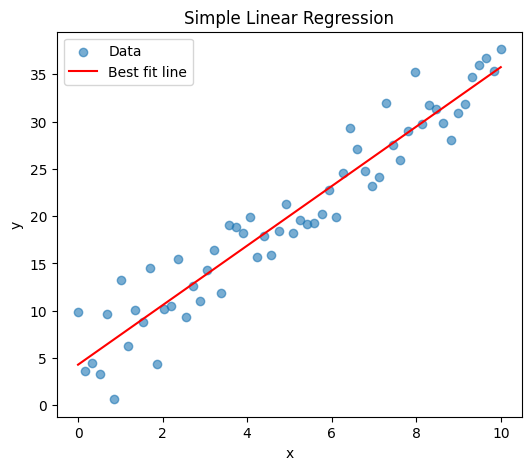

In [2]:
# Simple linear regression: visualize the "best fit line" concept
np.random.seed(1)
x_simple = np.linspace(0, 10, 60)
y_simple = 3 * x_simple + 5 + np.random.normal(0, 3, 60)

model_simple = LinearRegression()
model_simple.fit(x_simple.reshape(-1, 1), y_simple)

print(f"Learned equation: y = {model_simple.coef_[0]:.2f} * x + {model_simple.intercept_:.2f}")
print("(True relationship was y = 3x + 5 + noise)")

plt.figure(figsize=(6, 5))
plt.scatter(x_simple, y_simple, alpha=0.6, label="Data")
plt.plot(x_simple, model_simple.predict(x_simple.reshape(-1, 1)), color='red', label="Best fit line")
plt.xlabel("x"); plt.ylabel("y")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()


In [3]:
# Multiple linear regression on a synthetic dataset with several features
X_multi, y_multi, true_coef = make_regression(n_samples=200, n_features=4, n_informative=4,
                                                noise=10, coef=True, random_state=2)
feature_names = [f"x{i+1}" for i in range(4)]

model_multi = LinearRegression()
model_multi.fit(X_multi, y_multi)

comparison = pd.DataFrame({
    'feature': feature_names,
    'true_coefficient': true_coef,
    'learned_coefficient': model_multi.coef_
})
print(comparison)
print(f"\nLearned intercept: {model_multi.intercept_:.4f} (true intercept was 0)")
print("--> With enough clean data, linear regression recovers the true underlying coefficients closely.")


  feature  true_coefficient  learned_coefficient
0      x1           42.9104              43.3760
1      x2           17.4036              17.8765
2      x3           19.4110              18.4451
3      x4            5.5933               6.0956

Learned intercept: -0.0206 (true intercept was 0)
--> With enough clean data, linear regression recovers the true underlying coefficients closely.


## 2. Polynomial Regression

### What?
**Polynomial regression** extends linear regression by adding **polynomial terms** of the features ($x^2, x^3, \dots$), allowing the model to fit **curved** relationships — while still being "linear" in the *parameters*.

$$\hat{y} = w_0 + w_1 x + w_2 x^2 + \dots + w_d x^d$$

### Why?
Real-world relationships aren't always straight lines. Polynomial features let a linear model capture curvature without switching to a fundamentally different algorithm.

### How?
Transform the input features to include powers (e.g., via `PolynomialFeatures`), then fit ordinary linear regression on the *expanded* feature set.

⚠️ Higher-degree polynomials fit training data increasingly well but risk **overfitting** (recall Day 4's underfitting/overfitting visualization) — this is exactly why regularization (below) matters.


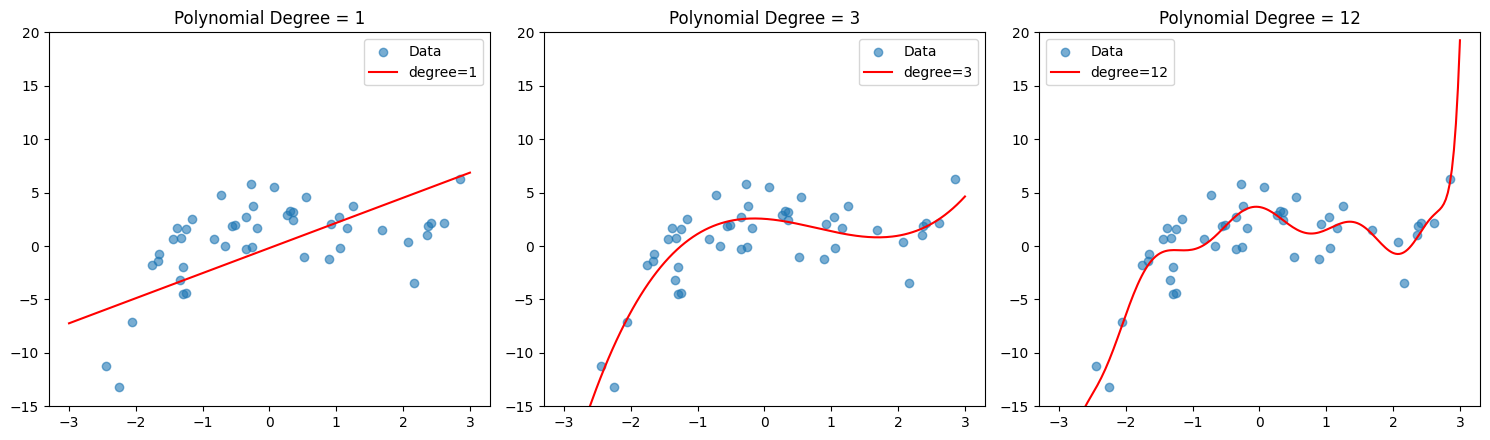

--> degree=1 underfits the cubic pattern; degree=3 matches it well; degree=12 overfits (wiggly).


In [4]:
# Polynomial regression: fit curves of different degrees to a non-linear relationship
np.random.seed(3)
x_nl = np.sort(np.random.uniform(-3, 3, 50))
y_nl = 0.5 * x_nl**3 - x_nl**2 + 2 + np.random.normal(0, 2, 50)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
x_plot = np.linspace(-3, 3, 200).reshape(-1, 1)

for ax, degree in zip(axes, [1, 3, 12]):
    poly_pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('linreg', LinearRegression())
    ])
    poly_pipeline.fit(x_nl.reshape(-1, 1), y_nl)
    y_plot = poly_pipeline.predict(x_plot)

    ax.scatter(x_nl, y_nl, alpha=0.6, label="Data")
    ax.plot(x_plot, y_plot, color='red', label=f"degree={degree}")
    ax.set_ylim(-15, 20)
    ax.set_title(f"Polynomial Degree = {degree}")
    ax.legend()

plt.tight_layout()
plt.show()
print("--> degree=1 underfits the cubic pattern; degree=3 matches it well; degree=12 overfits (wiggly).")


## 3. Cost Function & Gradient Descent (Recap from Day 2)

### What?
The most common cost function for linear regression is **Mean Squared Error (MSE)**:

$$J(\mathbf{w}) = \frac{1}{m}\sum_{i=1}^{m}\left(\hat{y}^{(i)} - y^{(i)}\right)^2$$

### Why?
This function is **convex** (bowl-shaped) for linear regression, guaranteeing that gradient descent converges to the **global minimum** — no risk of getting stuck in a local minimum, unlike many non-linear models.

### How?
As covered on Day 2: compute the gradient $\nabla J(\mathbf{w})$, update $\mathbf{w} \leftarrow \mathbf{w} - \alpha \nabla J(\mathbf{w})$, repeat until convergence.


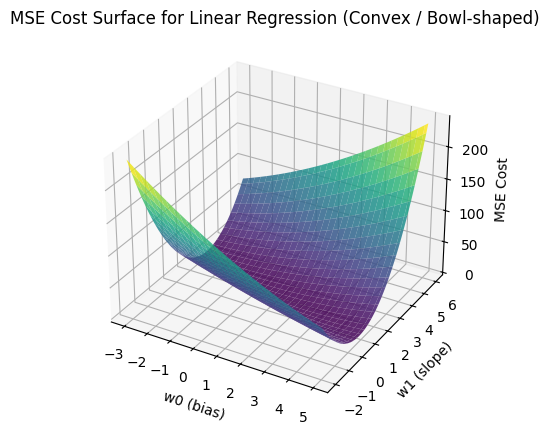

In [5]:
# Quick recap visualization: MSE cost surface is convex (bowl-shaped) for linear regression
np.random.seed(4)
x_r = np.random.rand(50, 1) * 5
y_r = 2 * x_r.ravel() + 1 + np.random.normal(0, 1, 50)

w0_range = np.linspace(-3, 5, 60)
w1_range = np.linspace(-2, 6, 60)
W0, W1 = np.meshgrid(w0_range, w1_range)
Cost = np.zeros_like(W0)

for i in range(W0.shape[0]):
    for j in range(W0.shape[1]):
        preds = W0[i, j] + W1[i, j] * x_r.ravel()
        Cost[i, j] = np.mean((preds - y_r) ** 2)

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W0, W1, Cost, cmap='viridis', alpha=0.85)
ax.set_xlabel('w0 (bias)'); ax.set_ylabel('w1 (slope)'); ax.set_zlabel('MSE Cost')
ax.set_title("MSE Cost Surface for Linear Regression (Convex / Bowl-shaped)")
plt.show()


## 4. The Normal Equation

### What?
A **closed-form solution** that directly computes the optimal weights without iterative gradient descent:

$$\mathbf{w} = (X^T X)^{-1} X^T \mathbf{y}$$

### Why?
No need to choose a learning rate or iterate — solves for the exact minimum of the MSE cost function in one step (recall Day 1's matrix inverse).

### How? / Trade-offs
| | Gradient Descent | Normal Equation |
|---|---|---|
| Works for large $n$ (features)? | Yes, scales well | No — computing $(X^TX)^{-1}$ is $O(n^3)$, slow for many features |
| Works for large $m$ (samples)? | Yes (esp. mini-batch/SGD) | Yes, but still needs the full matrix in memory |
| Requires feature scaling? | Yes (for faster convergence) | No |
| Requires choosing hyperparameters? | Yes (learning rate, iterations) | No |
| Fails when? | Poor LR choice → slow/diverges | $X^TX$ singular (multicollinearity, recall Day 1's rank) |


In [6]:
# Verify Normal Equation matches sklearn's LinearRegression (which uses a similar closed-form/SVD approach)
X_ne = np.hstack([np.ones((len(x_r), 1)), x_r])
w_normal_eq = np.linalg.inv(X_ne.T @ X_ne) @ X_ne.T @ y_r

sk_model = LinearRegression().fit(x_r, y_r)

print("Normal Equation weights [bias, slope]:", w_normal_eq.ravel())
print("sklearn LinearRegression: [bias, slope] =", [sk_model.intercept_, sk_model.coef_[0]])
print("\n--> Both methods arrive at (nearly) the same solution, as expected for a convex problem.")


Normal Equation weights [bias, slope]: [0.9457 2.0304]
sklearn LinearRegression: [bias, slope] = [np.float64(0.9456903805623362), np.float64(2.030413361986389)]

--> Both methods arrive at (nearly) the same solution, as expected for a convex problem.


## 5. Regression Assumptions

### What?
Classical linear regression relies on several assumptions for its coefficient estimates and statistical inferences to be valid:
1. **Linearity**: the relationship between features and target is linear.
2. **Independence**: residuals (errors) are independent of each other.
3. **Homoscedasticity**: residuals have constant variance across all predicted values (no "funnel" shape).
4. **Normality of residuals**: residuals are approximately normally distributed.
5. **No (or low) multicollinearity**: features aren't highly correlated with each other (recall Day 1's rank + Day 3's correlation).

### Why?
Violating these doesn't necessarily break predictions, but it **undermines the reliability of coefficient interpretation** (e.g., statistical significance, confidence intervals) and can signal that a different model or feature engineering approach is needed.

### How to check?
- **Linearity**: scatter plots of features vs. target.
- **Homoscedasticity**: plot residuals vs. predicted values — look for a random cloud, not a funnel/pattern.
- **Normality**: histogram or Q-Q plot of residuals.
- **Multicollinearity**: correlation matrix or Variance Inflation Factor (VIF).


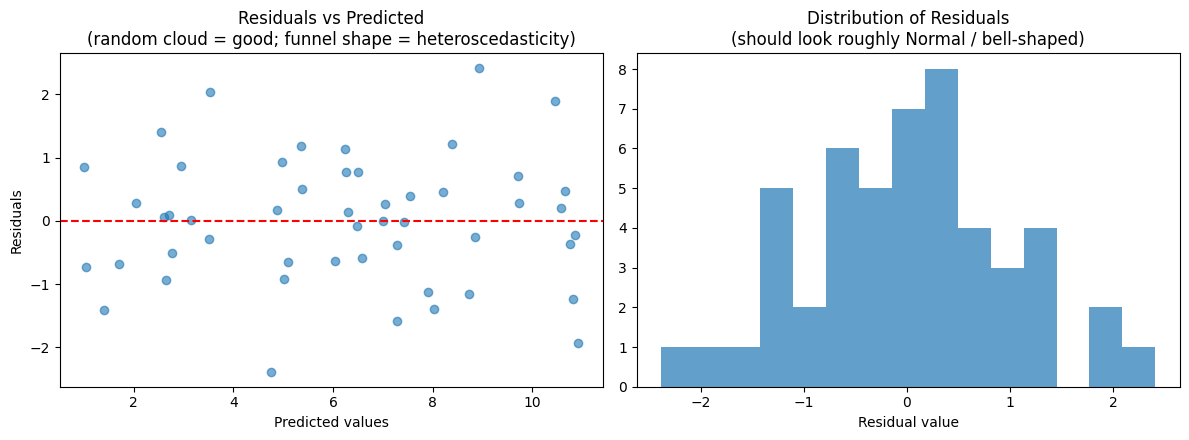

In [7]:
# Diagnostic plots: residuals vs predicted (homoscedasticity check) and residual distribution (normality check)
predictions = sk_model.predict(x_r)
residuals = y_r - predictions

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(predictions, residuals, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Predicted values"); axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Predicted\n(random cloud = good; funnel shape = heteroscedasticity)")

axes[1].hist(residuals, bins=15, alpha=0.7)
axes[1].set_title("Distribution of Residuals\n(should look roughly Normal / bell-shaped)")
axes[1].set_xlabel("Residual value")

plt.tight_layout()
plt.show()


## 6. Regularization: Ridge (L2) and Lasso (L1)

### What?
Regularization adds a **penalty term** to the cost function to discourage overly large weights, reducing overfitting.

- **Ridge Regression (L2 penalty)**:
  $$J(\mathbf{w}) = \text{MSE} + \lambda \sum_i w_i^2$$
- **Lasso Regression (L1 penalty)**:
  $$J(\mathbf{w}) = \text{MSE} + \lambda \sum_i |w_i|$$

$\lambda$ (sometimes called $\alpha$ in sklearn) controls the **strength** of regularization: $\lambda = 0$ recovers ordinary linear regression; larger $\lambda$ shrinks weights more aggressively.

### Why?
- Recall Day 1's L1/L2 norm visualization: the L1 penalty's "diamond" shape has corners on the axes, which is why **Lasso can shrink weights to exactly zero** — effectively performing automatic **feature selection**.
- Ridge's "circular" L2 penalty shrinks weights **smoothly toward zero** but rarely to *exactly* zero — it keeps all features but reduces their influence, useful when many features are mildly informative and/or **multicollinear**.

### How to choose?
| | Ridge (L2) | Lasso (L1) |
|---|---|---|
| Effect on weights | Shrinks smoothly | Can zero out weights entirely |
| Good for | Multicollinearity, many small/medium effects | Feature selection, sparse solutions |
| Use when | You believe most features matter somewhat | You believe only a few features truly matter |

*(Elastic Net combines both penalties — a blend of Ridge and Lasso — useful when you want some sparsity plus multicollinearity handling.)*


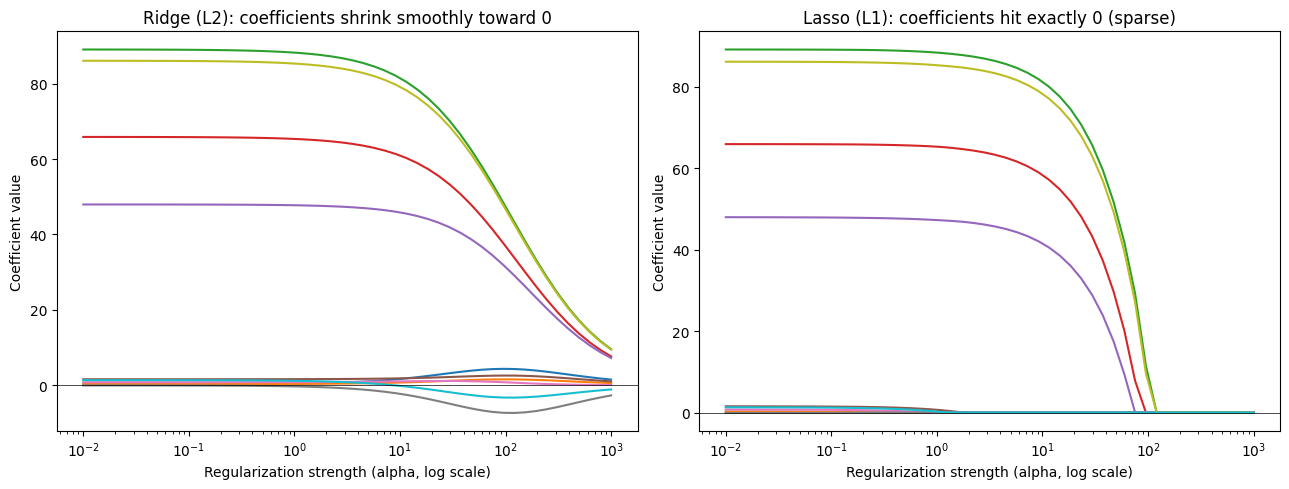

True number of uninformative features (coef=0): 6 out of 10
Lasso coefficients pushed to ~0 at high alpha: 10 out of 10
--> Lasso correctly identifies and zeroes out many of the uninformative features.


In [8]:
# Demonstrate Ridge vs Lasso: coefficient shrinkage as regularization strength increases
np.random.seed(5)
X_reg, y_reg, true_coefs = make_regression(n_samples=100, n_features=10, n_informative=4,
                                             noise=15, coef=True, random_state=5)
# Standardize features (important for regularized models -- penalty is scale-sensitive!)
X_reg_scaled = StandardScaler().fit_transform(X_reg)

alphas = np.logspace(-2, 3, 50)
ridge_coefs = []
lasso_coefs = []

for a in alphas:
    ridge = Ridge(alpha=a).fit(X_reg_scaled, y_reg)
    lasso = Lasso(alpha=a, max_iter=10000).fit(X_reg_scaled, y_reg)
    ridge_coefs.append(ridge.coef_)
    lasso_coefs.append(lasso.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for i in range(X_reg.shape[1]):
    axes[0].plot(alphas, ridge_coefs[:, i])
    axes[1].plot(alphas, lasso_coefs[:, i])

for ax, title in zip(axes, ["Ridge (L2): coefficients shrink smoothly toward 0",
                             "Lasso (L1): coefficients hit exactly 0 (sparse)"]):
    ax.set_xscale('log')
    ax.set_xlabel("Regularization strength (alpha, log scale)")
    ax.set_ylabel("Coefficient value")
    ax.set_title(title)
    ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

n_true_zero = np.sum(true_coefs == 0)
n_lasso_zero_at_high_alpha = np.sum(np.isclose(lasso_coefs[-1], 0))
print(f"True number of uninformative features (coef=0): {n_true_zero} out of {len(true_coefs)}")
print(f"Lasso coefficients pushed to ~0 at high alpha: {n_lasso_zero_at_high_alpha} out of {len(true_coefs)}")
print("--> Lasso correctly identifies and zeroes out many of the uninformative features.")


## 7. Bias–Variance Intuition

### What?
- **Bias**: error from overly simplistic assumptions — the model consistently misses the true pattern (underfitting).
- **Variance**: error from excessive sensitivity to the training data's noise — the model changes drastically with small changes in training data (overfitting).

Total expected error decomposes (conceptually) as:
$$\text{Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Noise}$$

### Why?
Regularization is fundamentally a **bias-variance trade-off tool**: increasing $\lambda$ increases bias slightly but reduces variance substantially, often lowering *total* test error, especially when the unregularized model overfits.

### How?
As regularization strength increases:
- Training error tends to **increase** (more bias).
- Test error typically **decreases at first** (less overfitting/variance), then **increases again** if regularization becomes too strong (underfitting).


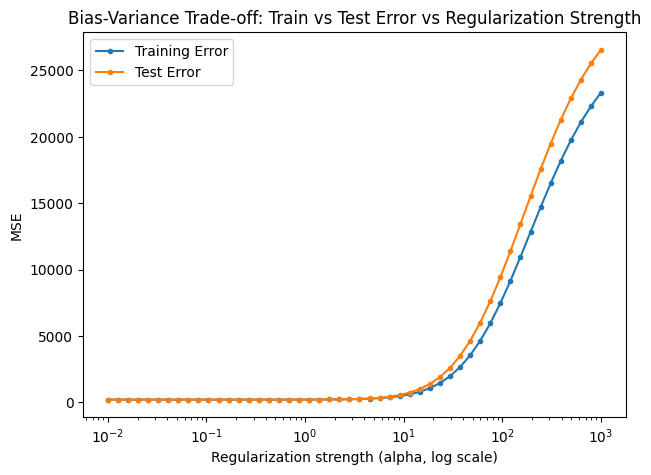

Best alpha (lowest test error): 0.5429
--> Too little regularization (low alpha, left side): higher variance, test error can be higher.
--> Too much regularization (high alpha, right side): higher bias, both errors rise together.


In [9]:
# Visualize the bias-variance trade-off: train vs test error as regularization strength increases
X_train_bv, X_test_bv, y_train_bv, y_test_bv = train_test_split(X_reg_scaled, y_reg, test_size=0.3, random_state=6)

train_errors, test_errors = [], []
for a in alphas:
    ridge = Ridge(alpha=a).fit(X_train_bv, y_train_bv)
    train_errors.append(mean_squared_error(y_train_bv, ridge.predict(X_train_bv)))
    test_errors.append(mean_squared_error(y_test_bv, ridge.predict(X_test_bv)))

plt.figure(figsize=(7, 5))
plt.plot(alphas, train_errors, label="Training Error", marker='o', markersize=3)
plt.plot(alphas, test_errors, label="Test Error", marker='o', markersize=3)
plt.xscale('log')
plt.xlabel("Regularization strength (alpha, log scale)")
plt.ylabel("MSE")
plt.title("Bias-Variance Trade-off: Train vs Test Error vs Regularization Strength")
plt.legend()
plt.show()

best_alpha_idx = np.argmin(test_errors)
print(f"Best alpha (lowest test error): {alphas[best_alpha_idx]:.4f}")
print("--> Too little regularization (low alpha, left side): higher variance, test error can be higher.")
print("--> Too much regularization (high alpha, right side): higher bias, both errors rise together.")


## 8. Coding Practice — Linear Regression From Scratch (with L2 Regularization)

We extend Day 2's from-scratch linear regression to optionally include Ridge-style L2 regularization, to see exactly how the penalty term modifies the gradient update.

Ridge gradient (derived from $J(\mathbf{w}) = \text{MSE} + \lambda \sum w_i^2$, excluding the bias term from the penalty):
$$\nabla J(\mathbf{w}) = \frac{2}{m} X^T (X\mathbf{w} - \mathbf{y}) + 2\lambda \mathbf{w}$$


In [10]:
class RidgeRegressionScratch:
    def __init__(self, learning_rate=0.1, n_iterations=1000, l2_penalty=0.0):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.l2_penalty = l2_penalty
        self.theta = None
        self.loss_history = []

    def _add_bias(self, X):
        return np.hstack([np.ones((X.shape[0], 1)), X])

    def fit(self, X, y):
        X_b = self._add_bias(X)
        m, n = X_b.shape
        self.theta = np.zeros((n, 1))
        y = y.reshape(-1, 1)

        for _ in range(self.n_iterations):
            predictions = X_b @ self.theta
            error = predictions - y

            # Regularize all weights EXCEPT the bias term (index 0)
            reg_term = self.l2_penalty * self.theta
            reg_term[0] = 0

            gradient = (2 / m) * X_b.T @ error + 2 * reg_term
            self.theta = self.theta - self.lr * gradient

            mse = np.mean(error ** 2)
            penalty_value = self.l2_penalty * np.sum(self.theta[1:] ** 2)
            self.loss_history.append(mse + penalty_value)

        return self

    def predict(self, X):
        X_b = self._add_bias(X)
        return (X_b @ self.theta).ravel()


# Compare no regularization vs strong L2 regularization on the noisy multi-feature dataset
model_no_reg = RidgeRegressionScratch(learning_rate=0.05, n_iterations=500, l2_penalty=0.0)
model_no_reg.fit(X_train_bv, y_train_bv)

model_with_reg = RidgeRegressionScratch(learning_rate=0.05, n_iterations=500, l2_penalty=1.0)
model_with_reg.fit(X_train_bv, y_train_bv)

print("Weights WITHOUT regularization (first 5):", model_no_reg.theta[1:6].ravel())
print("Weights WITH L2 regularization (first 5): ", model_with_reg.theta[1:6].ravel())
print("\n--> Regularized weights are noticeably smaller in magnitude (shrunk toward zero).")

# Compare against sklearn's Ridge to validate correctness
sk_ridge_check = Ridge(alpha=1.0).fit(X_train_bv, y_train_bv)
print("\nsklearn Ridge weights (first 5):", sk_ridge_check.coef_[:5])
print("Scratch Ridge weights (first 5): ", model_with_reg.theta[1:6].ravel())
print("--> Close match (small differences due to gradient descent vs sklearn's exact solver).")


Weights WITHOUT regularization (first 5): [ 0.6894  1.0437 90.1908 66.4911 47.7418]
Weights WITH L2 regularization (first 5):  [-1.8646  4.8501 42.9232 36.4551 31.1919]

--> Regularized weights are noticeably smaller in magnitude (shrunk toward zero).

sklearn Ridge weights (first 5): [ 0.6006  1.2667 88.6543 65.6801 47.4415]
Scratch Ridge weights (first 5):  [-1.8646  4.8501 42.9232 36.4551 31.1919]
--> Close match (small differences due to gradient descent vs sklearn's exact solver).


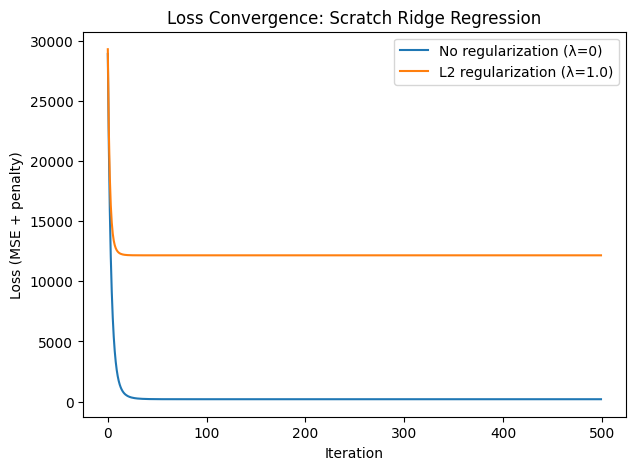

In [11]:
# Plot loss curves for both models
plt.figure(figsize=(7, 5))
plt.plot(model_no_reg.loss_history, label="No regularization (λ=0)")
plt.plot(model_with_reg.loss_history, label="L2 regularization (λ=1.0)")
plt.xlabel("Iteration"); plt.ylabel("Loss (MSE + penalty)")
plt.title("Loss Convergence: Scratch Ridge Regression")
plt.legend()
plt.show()


## 9. Coding Practice — Linear, Ridge, and Lasso with scikit-learn (Model Comparison)


In [12]:
# Train Linear, Ridge, and Lasso on the same dataset and compare
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0),
    'Lasso (alpha=0.1)': Lasso(alpha=0.1, max_iter=10000)
}

results = []
for name, model in models.items():
    model.fit(X_train_bv, y_train_bv)
    preds = model.predict(X_test_bv)
    mae = mean_absolute_error(y_test_bv, preds)
    mse = mean_squared_error(y_test_bv, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_bv, preds)
    n_zero_coefs = np.sum(np.isclose(model.coef_, 0)) if hasattr(model, 'coef_') else 0
    results.append({'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2, 'Zero Coefficients': n_zero_coefs})

results_df = pd.DataFrame(results).set_index('Model')
print(results_df)


                       MAE       MSE     RMSE      R2  Zero Coefficients
Model                                                                   
Linear Regression  11.5159  201.4821  14.1944  0.9928                  0
Ridge (alpha=1.0)  11.2873  200.2520  14.1510  0.9929                  0
Lasso (alpha=0.1)  11.4165  198.9316  14.1043  0.9929                  1


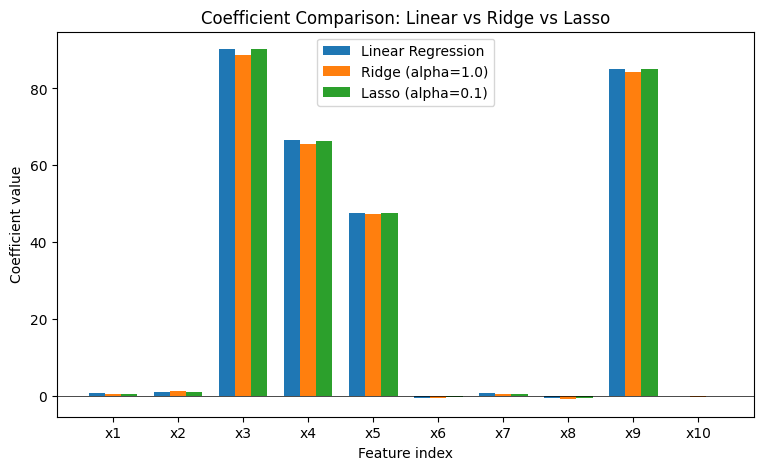

--> Notice Lasso zeroes out several coefficients entirely (sparse), while Ridge shrinks
    all coefficients but keeps them non-zero, and plain Linear Regression has the largest,
    least-constrained coefficient magnitudes.


In [13]:
# Visualize coefficient magnitudes across the three models
fig, ax = plt.subplots(figsize=(9, 5))
width = 0.25
x_pos = np.arange(X_reg.shape[1])

for i, (name, model) in enumerate(models.items()):
    ax.bar(x_pos + i * width, model.coef_, width=width, label=name)

ax.set_xlabel("Feature index")
ax.set_ylabel("Coefficient value")
ax.set_title("Coefficient Comparison: Linear vs Ridge vs Lasso")
ax.set_xticks(x_pos + width)
ax.set_xticklabels([f"x{i+1}" for i in range(X_reg.shape[1])])
ax.legend()
ax.axhline(0, color='black', linewidth=0.5)
plt.show()

print("--> Notice Lasso zeroes out several coefficients entirely (sparse), while Ridge shrinks")
print("    all coefficients but keeps them non-zero, and plain Linear Regression has the largest,")
print("    least-constrained coefficient magnitudes.")


## 10. Mini Project — House Price Prediction

**Goal:** Apply everything from today end-to-end on a (near-)real housing dataset: train Linear, Ridge, and Lasso regression, evaluate with MAE/MSE/RMSE/R², and interpret which model generalizes best.


In [14]:
# Load California Housing dataset (falls back to a synthetic housing-like dataset if offline)
try:
    housing = fetch_california_housing(as_frame=True)
    house_df = housing.frame
    print("Loaded California Housing dataset:", house_df.shape)
except Exception as e:
    print("Falling back to a synthetic housing dataset (no internet access):", e)
    np.random.seed(20)
    n = 3000
    house_df = pd.DataFrame({
        'MedInc': np.random.gamma(5, 1.5, n),
        'HouseAge': np.random.uniform(1, 52, n),
        'AveRooms': np.random.normal(5.5, 1.2, n),
        'AveBedrms': np.random.normal(1.1, 0.2, n),
        'Population': np.random.exponential(1200, n),
        'AveOccup': np.random.normal(3, 0.8, n),
        'Latitude': np.random.uniform(32, 42, n),
        'Longitude': np.random.uniform(-124, -114, n),
    })
    house_df['MedHouseVal'] = (
        0.4 * house_df['MedInc'] - 0.01 * house_df['HouseAge'] +
        0.05 * house_df['AveRooms'] - 0.002 * house_df['Population'] / 100 +
        np.random.normal(0, 0.5, n)
    ).clip(lower=0.2)

house_df.head()


/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_base.py:1519: UserWarning: Retry downloading from url: https://ndownloader.figshare.com/files/5976036
  warnings.warn(f"Retry downloading from url: {remote.url}")


Falling back to a synthetic housing dataset (no internet access): HTTP Error 403: Forbidden


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,10.2725,5.3289,4.4859,0.8630,452.9013,1.9397,32.5271,-121.4470,5.0447
1,7.6541,18.9853,2.8144,1.1014,894.9369,2.6844,34.5763,-114.6411,3.1238
2,8.2236,29.1638,5.5695,1.0395,601.1021,3.4914,41.4805,-118.9788,4.0519
3,1.8215,47.5244,6.4792,1.3578,994.0477,2.6297,37.7002,-117.9779,0.5349
4,10.5069,46.2874,5.9157,1.0482,362.3786,2.1929,32.6508,-120.4290,4.7373


In [15]:
# Prepare data: split, then scale (fit on train only!)
target_col = 'MedHouseVal'
X_house = house_df.drop(columns=[target_col])
y_house = house_df[target_col]

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_house, y_house, test_size=0.2, random_state=42)

scaler_house = StandardScaler()
X_train_h_scaled = scaler_house.fit_transform(X_train_h)
X_test_h_scaled = scaler_house.transform(X_test_h)

print("Train shape:", X_train_h_scaled.shape, "| Test shape:", X_test_h_scaled.shape)


Train shape: (2400, 8) | Test shape: (600, 8)


In [16]:
# Train and evaluate Linear, Ridge, Lasso on the housing data
house_models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01, max_iter=10000)
}

house_results = []
predictions_dict = {}

for name, model in house_models.items():
    model.fit(X_train_h_scaled, y_train_h)
    preds = model.predict(X_test_h_scaled)
    predictions_dict[name] = preds

    mae = mean_absolute_error(y_test_h, preds)
    mse = mean_squared_error(y_test_h, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_h, preds)

    house_results.append({'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2})

house_results_df = pd.DataFrame(house_results).set_index('Model')
print(house_results_df)

best_model_name = house_results_df['R2'].idxmax()
print(f"\nBest model by R²: {best_model_name}")


                      MAE     MSE    RMSE      R2
Model                                            
Linear Regression  0.4064  0.2537  0.5037  0.8740
Ridge              0.4065  0.2537  0.5037  0.8739
Lasso              0.4083  0.2558  0.5058  0.8729

Best model by R²: Linear Regression


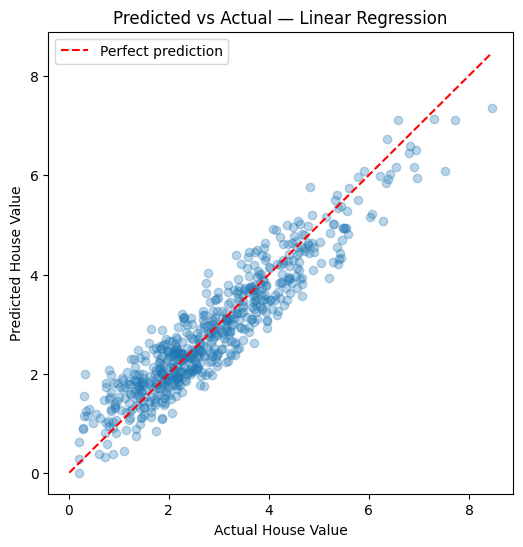

In [17]:
# Visualize predicted vs actual for the best model
best_preds = predictions_dict[best_model_name]

plt.figure(figsize=(6, 6))
plt.scatter(y_test_h, best_preds, alpha=0.3)
lims = [min(y_test_h.min(), best_preds.min()), max(y_test_h.max(), best_preds.max())]
plt.plot(lims, lims, color='red', linestyle='--', label='Perfect prediction')
plt.xlabel("Actual House Value"); plt.ylabel("Predicted House Value")
plt.title(f"Predicted vs Actual — {best_model_name}")
plt.legend()
plt.show()


## 11. Regression Metrics: MAE, MSE, RMSE, R²

### What?
- **MAE (Mean Absolute Error)**: average of absolute differences. Same units as target; robust to outliers.
  $$\text{MAE} = \frac{1}{m}\sum |y_i - \hat{y}_i|$$
- **MSE (Mean Squared Error)**: average of squared differences. Penalizes large errors more heavily.
  $$\text{MSE} = \frac{1}{m}\sum (y_i - \hat{y}_i)^2$$
- **RMSE (Root MSE)**: square root of MSE — brings the metric back to the target's original units.
  $$\text{RMSE} = \sqrt{\text{MSE}}$$
- **R² (Coefficient of Determination)**: proportion of variance in the target explained by the model (1.0 = perfect, 0 = no better than predicting the mean, can go negative for very bad models).
  $$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

### Why?
Different metrics highlight different failure modes:
- Use **MAE** when you want a metric robust to outliers and easy to interpret in original units.
- Use **RMSE** when large errors should be penalized disproportionately more (e.g., a $100k pricing error is much worse than 10 errors of $10k).
- Use **R²** to communicate "percentage of variance explained" to non-technical stakeholders — but note it can be misleading with non-linear relationships or few data points.

### How?
Always report **multiple metrics together** — a single number rarely tells the full story about model quality.


In [18]:
# Manually compute all four metrics from scratch and verify against sklearn
y_true_sample = y_test_h.values
y_pred_sample = best_preds

mae_scratch = np.mean(np.abs(y_true_sample - y_pred_sample))
mse_scratch = np.mean((y_true_sample - y_pred_sample) ** 2)
rmse_scratch = np.sqrt(mse_scratch)
ss_res = np.sum((y_true_sample - y_pred_sample) ** 2)
ss_tot = np.sum((y_true_sample - y_true_sample.mean()) ** 2)
r2_scratch = 1 - (ss_res / ss_tot)

print("Scratch vs sklearn metrics:")
print(f"MAE:  scratch={mae_scratch:.4f}  | sklearn={mean_absolute_error(y_true_sample, y_pred_sample):.4f}")
print(f"MSE:  scratch={mse_scratch:.4f}  | sklearn={mean_squared_error(y_true_sample, y_pred_sample):.4f}")
print(f"RMSE: scratch={rmse_scratch:.4f}")
print(f"R2:   scratch={r2_scratch:.4f}  | sklearn={r2_score(y_true_sample, y_pred_sample):.4f}")


Scratch vs sklearn metrics:
MAE:  scratch=0.4064  | sklearn=0.4064
MSE:  scratch=0.2537  | sklearn=0.2537
RMSE: scratch=0.5037
R2:   scratch=0.8740  | sklearn=0.8740


## ML Connection Recap

| Concept | Connects to |
|---|---|
| MSE cost function | Day 2's derivative/gradient descent foundations |
| Normal Equation | Day 1's matrix inverse |
| Ridge / Lasso penalties | Day 1's L1/L2 norms |
| Multicollinearity motivating Ridge | Day 1's rank, Day 3's correlation |
| Feature scaling before regularization | Day 4's standardization |
| Bias-variance trade-off | Day 4's overfitting/underfitting visualization |


## 12. Interview Questions — Practice Aloud (Close Your Notes!)

1. **What is the difference between Ridge and Lasso regression?**
   *Hint: L2 vs L1 penalty; Ridge shrinks smoothly, Lasso can zero out coefficients (feature selection).*

2. **Why does Lasso produce sparse solutions but Ridge doesn't?**
   *Hint: geometric intuition from Day 1 — L1's diamond-shaped constraint region has corners on the axes.*

3. **What assumptions does linear regression make, and what happens if they're violated?**
   *Hint: linearity, independence, homoscedasticity, normality of residuals, low multicollinearity.*

4. **When would you choose the Normal Equation over gradient descent, or vice versa?**
   *Hint: Normal Equation is great for small feature counts; gradient descent scales to large/high-dimensional datasets.*

5. **Explain the bias-variance trade-off and how regularization relates to it.**
   *Hint: regularization increases bias slightly to reduce variance, often lowering total test error.*

6. **Why do we use RMSE instead of MSE sometimes?**
   *Hint: RMSE is in the same units as the target, making it more interpretable.*

7. **(Bonus) Can R² be negative? What does that mean?**
   *Hint: yes — it means the model performs worse than simply predicting the mean of the target for every sample.*


## 13. Active Recall & Daily Output

**Self-check (mark ✔ only if you can do this without notes):**
- [ ] Write the equation for simple and multiple linear regression from memory.
- [ ] Explain how polynomial regression is still "linear" despite fitting curves.
- [ ] Derive/recall the Normal Equation and state one situation where it's impractical.
- [ ] List the 5 assumptions of linear regression and one way to check each.
- [ ] Write the Ridge and Lasso cost functions from memory, and explain why Lasso induces sparsity.
- [ ] Explain the bias-variance trade-off and connect it to regularization strength.
- [ ] Implement Ridge regression with gradient descent from scratch.
- [ ] Compute MAE, MSE, RMSE, and R² by hand and explain when to prefer each.

### 📌 Daily Output (per the planner)
**Mini Project: House Price Prediction** (Section 10) — Linear, Ridge, and Lasso regression trained and compared on a housing dataset, evaluated with MAE, MSE, RMSE, and R², with the best model identified and its predictions visualized against actual values.

Close this notebook and re-implement `RidgeRegressionScratch` and the model comparison table from memory — that's the real test of Day 5 mastery.
